<a href="https://colab.research.google.com/github/heisenberg304/Housing-Prices-prediction/blob/develop/Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

#Modeling

│

├── Dummy Regressor

├── Linear Regression

├── Ridge Regression

├── Lasso Regression

├── Decision Tree Regressor

├── Random Forest Regressor

├── Gradient Boosting

└── XGBoost

---

# Model Analysis

│

├── Baseline and Linear Models

├── Tree-Based Models

├── Boosting Models

├── Model Comparison

├── Feature Importance (XGBoost)

└── Prediction Error Analysis

---

#LOAD DATA

In [1]:
%%writefile data_loading.py
import pandas as pd
from sklearn.model_selection import train_test_split

#cargar datos
# data train no filled
train_not_filled = pd.read_csv("/content/drive/MyDrive/house_prices_advanced/HP_train_not_filled_encoding.csv")

# data train filled
train_filled = pd.read_csv("/content/drive/MyDrive/house_prices_advanced/HP_train_filled_encoding.csv")

#x,y
y = train_filled["SalePrice"]
x = train_filled.drop("SalePrice", axis=1)

#x,y
y_nf = train_not_filled["SalePrice"]
x_nf = train_not_filled.drop("SalePrice", axis=1)


def split_dataset(x, y):  #split 80/20
  x_train, x_test, y_train, y_test = train_test_split(
      x,
      y,
      test_size = 0.2,
      random_state=42
  )
  return x_train, x_test, y_train, y_test
x_train, x_test, y_train, y_test = split_dataset(x, y)
x_train_nf, x_test_nf, y_train_nf, y_test_nf = split_dataset(x_nf, y_nf)

Writing data_loading.py


In [2]:
%%writefile modeling_def.py
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

#entrenar modelo
def entrenar_model(model, x, y):
  return model.fit(x,y)

#predicciones del modelo
def predict_model(model, x):
  return model.predict(x)

#metricas del modelo
def evaluate_model(y_true, y_pred):
  MSE = mean_squared_error(y_true, y_pred)
  RMSE = root_mean_squared_error(y_true, y_pred)
  MAE = mean_absolute_error(y_true, y_pred)
  R2 = r2_score(y_true, y_pred)
  return MSE, RMSE, MAE, R2

#creando kflod
def k_fold():
  kfold = KFold(n_splits=5,
                shuffle=True,
                random_state=42)
  return kfold

#validacion cruzada
def cross_val(x_train, y_train, model, kfold):
  cv = cross_val_score(
        estimator=model,
        X=x_train,
        y=y_train,
        cv=kfold,
        scoring="neg_root_mean_squared_error"
        )
  return cv

#promedio y desviacion estandar de la validacion cruzada
def cv_mean_std(cv):
  cv = (cv * -1)
  cv_std = round(float(cv.std()), 3)
  cv_mean = round(float(cv.mean()), 3)
  return cv_std, cv_mean


Writing modeling_def.py


#Baseline
   - Dummy

In [ ]:
#Dummy Regressor
from data_loading import x_train, y_train, x_test, y_test
from sklearn.dummy import DummyRegressor
from modeling_def import entrenar_model, predict_model, evaluate_model

#modelo
model = DummyRegressor()

#entrenar modelo
modelo_entrenado = entrenar_model(model, x_train, y_train)

#predicciones del modelo
predict = predict_model(modelo_entrenado, x_test)

#metricas del modelo
MSE, RMSE, MAE, R2 = evaluate_model(y_test, predict)

#print(f' Root Mean Squared Error: {RMSE}\n Mean Absolute Error: {MAE}\n R2 Score: {R2} \n Mean Squared Error: {MSE}')

#Linear Models
   - Linear
   - Ridge
   - Lasso

In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from data_loading import x_train, y_train, x_test, y_test
from modeling_def import entrenar_model, predict_model, evaluate_model

#modelo
model = LinearRegression()

#entrenar modelo
modelo_entrenado = entrenar_model(model, x_train, y_train)


#entrenar modelo
modelo_entrenado = entrenar_model(model, x_train, y_train)

#predicciones del modelo
predict = predict_model(modelo_entrenado, x_test)

#metricas del modelo
MSE, RMSE, MAE, R2 = evaluate_model(y_test, predict)

#print(f' Root Mean Squared Error: {RMSE}\n Mean Absolute Error: {MAE}\n R2 Score: {R2} \n Mean Squared Error: {MSE}')

In [ ]:
#Ridge Regression
from sklearn.linear_model import Ridge
from data_loading import x_train, y_train, x_test, y_test
from modeling_def import entrenar_model, predict_model, evaluate_model, k_fold, cross_val, cv_mean_std

#modelo
model = Ridge(alpha=10)

#entrenar modelo
modelo_entrenado = entrenar_model(model, x_train, y_train)

#predicciones del modelo
predict = predict_model(modelo_entrenado, x_test)

#metricas del modelo
MSE, RMSE, MAE, R2 = evaluate_model(y_test, predict)

#validacion cruzada
kfold = k_fold()
cv = cross_val(x_train, y_train, model, kfold)
cv_std, cv_mean = cv_mean_std(cv)

#print(f' Root Mean Squared Error: {RMSE}\n Mean Absolute Error: {MAE}\n R2 Score: {R2} \n Mean Squared Error: {MSE}')
#print(f'Promedio validacion cruzada: {cv_mean} \nDesviacion estandar {cv_std}')

In [ ]:
#Lasso Regression
from sklearn.model_selection import KFold, cross_val_score

from sklearn.linear_model import Lasso
from data_loading import x_train, y_train, x_test, y_test
from modeling_def import entrenar_model, predict_model, evaluate_model, k_fold, cross_val, cv_mean_std

#modelo
model = Lasso(alpha=200)

#entrenar modelo
modelo_entrenado = entrenar_model(model, x_train, y_train)

#predicciones del modelo
predict = predict_model(modelo_entrenado, x_test)

#metricas del modelo
MSE, RMSE, MAE, R2 = evaluate_model(y_test, predict)

#validacion cruzada
kfold = k_fold()
cv = cross_val(x_train, y_train, model, kfold)
cv_std, cv_mean = cv_mean_std(cv)

#print(f' Root Mean Squared Error: {RMSE}\n Mean Absolute Error: {MAE}\n R2 Score: {R2} \n Mean Squared Error: {MSE}')
#print(f'Promedio validacion cruzada: {cv_mean} \nDesviacion estandar {cv_std}')

#Tree Models
   - Decision Tree Regressor
   - Random Forest Regressor

In [ ]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
from data_loading import x_train, y_train, x_test, y_test
from modeling_def import entrenar_model, predict_model, evaluate_model, k_fold, cross_val, cv_mean_std

#modelo
model = DecisionTreeRegressor(max_depth=7,          #7
                              min_samples_split=3,  #3
                              min_samples_leaf=1,   #1
                              random_state=7
)

#entrenar modelo
modelo_entrenado = entrenar_model(model, x_train, y_train)

#predicciones del modelo
predict = predict_model(modelo_entrenado, x_test)

#metricas del modelo
MSE, RMSE, MAE, R2 = evaluate_model(y_test, predict)

#validacion cruzada
kfold = k_fold()
cv = cross_val(x_train, y_train, model, kfold)
cv_std, cv_mean = cv_mean_std(cv)

#print(f' Root Mean Squared Error: {RMSE}\n Mean Absolute Error: {MAE}\n R2 Score: {R2} \n Mean Squared Error: {MSE}')
#print(f'Promedio validacion cruzada: {cv_mean} \nDesviacion estandar {cv_std}')

In [ ]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from data_loading import x_train, y_train, x_test, y_test
from modeling_def import entrenar_model, predict_model, evaluate_model, k_fold, cross_val, cv_mean_std

#modelo
model = RandomForestRegressor(n_estimators= 150, #100-150
                              #max_depth= ,      #default
                              min_samples_leaf=1,#default
                              min_samples_split=2, #default
                              max_features=None, #default
                              random_state= 3
)
#entrenar modelo
modelo_entrenado = entrenar_model(model, x_train, y_train)

#predicciones del modelo
predict = predict_model(modelo_entrenado, x_test)

#metricas del modelo
MSE, RMSE, MAE, R2 = evaluate_model(y_test, predict)

#validacion cruzada
kfold = k_fold()
cv = cross_val(x_train, y_train, model, kfold)
cv_std, cv_mean = cv_mean_std(cv)

#print(f' Root Mean Squared Error: {RMSE}\n Mean Absolute Error: {MAE}\n R2 Score: {R2} \n Mean Squared Error: {MSE}')
#print(f'Promedio validacion cruzada: {cv_mean} \nDesviacion estandar {cv_std}')

#Boosting Models
   - Gradient Boosting Regressor
   - XGBoost Regressor

In [ ]:
#Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
from data_loading import x_train, y_train, x_test, y_test
from modeling_def import entrenar_model, predict_model, evaluate_model, k_fold, cross_val, cv_mean_std

#modelo
model = GradientBoostingRegressor(learning_rate=0.08, #0.07 - 0.08
                                  n_estimators=200, #200
                                  max_depth=6, #6
                                  subsample=0.9, #0.8 - 0.9
                                  random_state=5
)
#entrenar modelo
modelo_entrenado = entrenar_model(model, x_train, y_train)

#predicciones del modelo
predict = predict_model(modelo_entrenado, x_test)

#metricas del modelo
MSE, RMSE, MAE, R2 = evaluate_model(y_test, predict)

#validacion cruzada
kfold = k_fold()
cv = cross_val(x_train, y_train, model, kfold)
cv_std, cv_mean = cv_mean_std(cv)

#print(f' Root Mean Squared Error: {RMSE}\n Mean Absolute Error: {MAE}\n R2 Score: {R2} \n Mean Squared Error: {MSE}')
#print(f'Promedio validacion cruzada: {cv_mean} \nDesviacion estandar {cv_std}')

In [46]:
%%writefile best_model.py
#XG Boost Regressor
from xgboost import XGBRegressor
from data_loading import x_train, y_train, x_test, y_test
from modeling_def import entrenar_model, predict_model, evaluate_model, k_fold, cross_val, cv_mean_std
import matplotlib.pyplot as plt
import pandas as pd

#modelo
model = XGBRegressor(learning_rate=0.11, #0.1
                     n_estimators=170, #150-180
                     max_depth=6, #6
                     subsample=0.9, #0.9
                     colsample_bytree=0.8, #0.8
                     gamma=1, #No hace nada
                     min_child_weight=2, #2
                     random_state= 5
)

#entrenar modelo
modelo_entrenado = entrenar_model(model, x_train, y_train)

#predicciones del modelo
predict = predict_model(modelo_entrenado, x_test)

#metricas del modelo
MSE, RMSE, MAE, R2 = evaluate_model(y_test, predict)

#validacion cruzada
kfold = k_fold()
cv = cross_val(x_train, y_train, model, kfold)
cv_std, cv_mean = cv_mean_std(cv)

#print(f' Root Mean Squared Error: {RMSE}\n Mean Absolute Error: {MAE}\n R2 Score: {R2} \n Mean Squared Error: {MSE}')
#print(f'Promedio validacion cruzada: {cv_mean} \nDesviacion estandar {cv_std}')



Writing best_model.py


In [45]:
#XG Boost Regressor
from xgboost import XGBRegressor
from data_loading import y_train_nf, x_train_nf, y_test_nf, x_test_nf
from modeling_def import entrenar_model, predict_model, evaluate_model, k_fold, cross_val, cv_mean_std
import matplotlib.pyplot as plt
import pandas as pd


#modelo
model = XGBRegressor(learning_rate=0.15, #0.1
                     n_estimators=190, #150-200
                     max_depth=6, #6
                     subsample=0.9, #0.9
                     colsample_bytree=1, #default
                     gamma=1, #No hace nada
                     min_child_weight=2, #2
                     random_state= 5
)
#entrenar modelo
modelo_entrenado_nf = entrenar_model(model, x_train_nf, y_train_nf)

#predicciones del modelo
predict_nf = predict_model(modelo_entrenado_nf, x_test_nf)

#metricas del modelo
MSE, RMSE, MAE, R2 = evaluate_model(y_test_nf, predict_nf)

#validacion cruzada
kfold = k_fold()
cv = cross_val(x_train_nf, y_train_nf, model, kfold)
cv_std, cv_mean = cv_mean_std(cv)

#print(f' Root Mean Squared Error: {RMSE}\n Mean Absolute Error: {MAE}\n R2 Score: {R2} \n Mean Squared Error: {MSE}')
#print(f'Promedio validacion cruzada: {cv_mean} \nDesviacion estandar {cv_std}')

---

El objetivo de este proyecto fue comparar diferentes familias de modelos de regresión para identificar cuál ofrecía el mejor desempeño en la predicción del precio de viviendas. Además de seleccionar el modelo con mejores resultados, se buscó comprender las fortalezas, limitaciones y comportamiento de cada algoritmo frente al mismo conjunto de datos y bajo las mismas condiciones de preprocesamiento.


La selección del mejor modelo se realizó principalmente mediante las métricas RMSE, MAE y R², las cuales permitieron evaluar tanto la magnitud del error como la capacidad explicativa de cada algoritmo. Adicionalmente, se empleó validación cruzada (K-Fold Cross Validation) para obtener una estimación más estable del rendimiento y reducir la dependencia de un único train-test split, proporcionando una evaluación más confiable de la capacidad de generalización de los modelos.

---

---
#Tabla comparativa: Baseline & Linear Models
---

| Linear Model | RMSE ↓ | MAE ↓ | R² ↑ |
|---------|--------:|-------:|------:|
| Dummy | 87619.03 | 62575.926 | -0.00088 |
| Linear Regression| 83119.01 | 23911.31 | 0.099286 |
| Ridge (alpha=0.1) | 32616.5 | 19495.6 | 0.86130 |
| Ridge (default) | 30502.54 | 19735.23 | 0.87870 |
| Ridge (alpha=10)| 30556.64 | 18873.65 | 0.87827 |
| Ridge (alpha=100) | 32563.56 | 18873.41 | 0.86175 |
| Lasso (alpha=0.1) | 36125.65 | 19674.17 | 0.8299 |
| Lasso (default) | 35364.56 | 19381.04 | 0.83695 |
| Lasso (alpha=10) | 34986.26 | 18713.33 | 0.84042 |
| Lasso (alpha=100) | 31226.81 | 18633.83 | 0.87287 |
| Lasso (alpha=200) | 31110.26 | 18271.8 | 0.87382 |
---



---
# Análisis de Modelos Baseline y Lineales
---


El **Dummy Regressor** se utilizó como línea base (baseline) para comparar el desempeño del resto de los modelos. Su bajo rendimiento confirmó que el conjunto de datos contiene patrones que pueden ser aprendidos por modelos más complejos.

La **Regresión Lineal** obtuvo un RMSE elevado y un R² muy bajo, indicando que una relación lineal no es suficiente para representar el problema de House Prices. Aunque su MAE fue considerablemente menor que el RMSE, la baja capacidad explicativa del modelo demuestra que existen relaciones no lineales que este algoritmo no logra capturar.

**Ridge Regression** mejoró significativamente el rendimiento respecto a la Regresión Lineal gracias a la regularización L2, obteniendo una mejor capacidad de generalización. El ajuste del hiperparámetro α produjo únicamente pequeñas variaciones, alcanzando el mejor equilibrio aproximadamente en α = 10. Valores superiores comenzaron a deteriorar el rendimiento debido a una regularización excesiva.

**Lasso Regression** obtuvo un desempeño competitivo, aunque ligeramente inferior al de Ridge. La regularización L1 permitió mejorar progresivamente las métricas a medida que aumentaba α, aunque las ganancias fueron cada vez menores, indicando un punto cercano al rendimiento óptimo. Dentro del rango evaluado no se observó una degradación del modelo, aunque valores considerablemente mayores podrían provocar underfitting.


---
#Tabla comparativa: Tree Models
---

| Tree Model | RMSE ↓ | MAE ↓ | R² ↑ |
|---------|--------:|-------:|------:|
| Decision Tree (default) | 40969.49 | 27266.78 | 0.78117 |
| Decision Tree (best) | 35597.6 | 24211.36 | 0.83479 |
| Random Forest (default) | 29235.14 | 17714.42 | 0.88857 |
| Random Forest (best) | 28906.58 | 17504.08 | 0.89106 |

---



---
# Análisis de Modelos Tree
---

El **Decision Tree Regressor** obtuvo un rendimiento inferior al de **Random Forest Regressor** debido a que basa todas sus predicciones en un único árbol de decisión. Esto lo hace más propenso al overfitting, ya que puede aprender patrones muy específicos del conjunto de entrenamiento y perder capacidad de generalización. Por el contrario, Random Forest combina múltiples árboles entrenados sobre diferentes subconjuntos de datos y variables, reduciendo la varianza del modelo y obteniendo predicciones más estables y robustas.

El ajuste de los hiperparámetros mejoró el rendimiento de ambos modelos, aunque el impacto fue mucho mayor en Decision Tree. Reducir la profundidad máxima (max_depth) y establecer restricciones mediante min_samples_leaf y min_samples_split permitió disminuir el sobreajuste y mejorar la capacidad de generalización. En Random Forest, las mejoras fueron más moderadas; aumentar el número de árboles (n_estimators) redujo ligeramente el error, aunque incrementó el tiempo de entrenamiento, por lo que se seleccionó una configuración que equilibrara rendimiento y eficiencia.

Los resultados obtenidos muestran cómo los métodos de ensamble pueden superar de forma consistente a un árbol de decisión individual. Mientras que **Decision Tree** depende completamente de una única estructura de decisión, **Random Forest** aprovecha la combinación de múltiples árboles para reducir la influencia de errores individuales, obteniendo un modelo más preciso y con mejor capacidad de generalización.

---
#Tabla comparativa: Boosting Models
---

| Tree Model | RMSE ↓ | MAE ↓ | R² ↑ |
|---------|--------:|-------:|------:|
| Gradient Boosting (default) | 28656.91 | 17391.25 | 0.89294 |
| Gradient Boosting (best) | 25698.39 | 16015.58 | 0.91390 |
| XG Boost (default) | 27970.32 | 18042.61 | 0.89800 |
| XG Boost (best) | 24100.17 | 15489.14 | 0.92428 |
| XGBoost NaN handled natively (default) | 28267.21 | 17823.19 | 0.89583 |
| XGBoost NaN handled natively (best) | 24567.6 | 15939.87 | 0.92131 |

---

---
# Análisis de Modelos Boosting
---

**Gradient Boosting** también utiliza múltiples árboles de decisión, pero a diferencia de Random Forest, los árboles no se entrenan de forma independiente. Cada árbol se construye secuencialmente para corregir los errores del árbol anterior. Esta estrategia permite que el modelo aprenda progresivamente patrones cada vez más complejos y reduzca el error residual.


Durante las pruebas realizadas, el hiperparámetro que produjo la mayor mejora fue learning_rate, ya que controla cuánto contribuye cada árbol al modelo final. Ajustarlo permitió reducir el RMSE sin necesidad de aumentar excesivamente la complejidad del modelo.


En este proyecto, XGBoost redujo el RMSE de 25698 (Gradient Boosting) a 24100, además de obtener el mayor R² (0.924), por lo que fue seleccionado como el mejor modelo.
**XGBoost** obtuvo el mejor desempeño porque combina el aprendizaje secuencial del Gradient Boosting con optimizaciones adicionales, como regularización, un mejor manejo del proceso de entrenamiento y una optimización más eficiente de los árboles. En este proyecto consiguió el menor RMSE, el menor MAE y el mayor R², demostrando una mejor capacidad para modelar la relación entre las variables del conjunto de datos.


En este proyecto, **XGBoost** obtuvo un rendimiento muy similar utilizando los valores faltantes originales y utilizando el conjunto completamente imputado. Esto indica que la capacidad nativa de XGBoost para manejar valores faltantes fue suficiente para este conjunto de datos. Sin embargo, este resultado no implica que el preprocesamiento sea innecesario en todos los proyectos, ya que otros algoritmos utilizados en esta investigación (como Ridge, Lasso o Random Forest de scikit-learn) requieren un tratamiento previo de los valores faltantes para poder entrenarse correctamente.


---
#Tabla comparativa de los mejores modelos
---

| Modelo | RMSE ↓ | MAE ↓ | R² ↑ | CV RMSE | CV STD |
|---------|--------:|-------:|------:|------:|------:|
| Ridge Regression| 30556.638 | 18873.65 | 0.87827 | 32020.029  | 7546.345 |
| Lasso Regression| 31110.26 | 18271.797 | 0.8738 | 32073.645 | 7937.017 |
| Decision Tree Regressor| 35597.6 | 24211.356 | 0.83479 | 38768.336 | 4323.641 |
| Random Forest Regressor| 28906.5 | 17504.08 | 0.891062 | 30665.098 | 4980.019 |
| Gradient Boosting Regressor| 25698.39 | 16015.58 | 0.91390 | 28870.457 | 5383.561 |
| **XGBoost Regressor**| **24100.17** | **15489.14** | **0.92428** | **28429.844** | **4711.865** |
| XGBoost NaN handled natively| 24567.6 | 15939.87 | 0.92131 | 29148.083 | 5746.988 |
---


---
# Análisis general
---
## Comparación general de los modelos

El modelo que obtuvo el mejor desempeño en las tres métricas principales (RMSE, MAE y R²) fue **XGBoost Regressor** utilizando el conjunto de datos previamente imputado. Este modelo logró el menor error de predicción y la mayor capacidad explicativa entre todos los modelos evaluados.

Sin embargo, la diferencia con **XGBoost Regressor** entrenado sobre los datos sin imputar fue pequeña. Esto demuestra la capacidad de XGBoost para manejar valores faltantes de forma nativa, obteniendo un rendimiento muy competitivo incluso sin realizar una imputación manual.


## Análisis de la validación cruzada

En todos los modelos evaluados, el CV RMSE fue ligeramente superior al RMSE obtenido sobre el conjunto de prueba. No obstante, las diferencias fueron relativamente pequeñas, oscilando aproximadamente entre 1000 y 4000 unidades, lo que indica que los resultados obtenidos durante la validacion fueron consistentes y que el conjunto de prueba no produjo estimaciones excesivamente optimistas.

El hecho de que el RMSE del conjunto de prueba sea cercano al promedio obtenido mediante K-Fold Cross Validation indica que los modelos presentan una buena capacidad de generalización y que el rendimiento observado no depende únicamente de una partición específica de los datos.

Considerando el CV RMSE, XGBoost obtuvo el mejor rendimiento promedio durante la validación cruzada y, además, presentó una desviación estándar baja, lo que indica un comportamiento consistente entre los diferentes folds. El modelo entrenado sin imputación obtuvo un resultado muy similar, lo que confirma nuevamente la robustez de XGBoost frente a los valores faltantes.

El modelo que presentó el mayor CV RMSE fue **Decision Tree Regressor**. Esto puede explicarse porque un árbol de decisión individual suele ser más propenso al sobreajuste, ya que todas las decisiones dependen de una única estructura de árbol, sin el beneficio del promedio o la corrección secuencial utilizada por los métodos de ensamble.

La menor desviación estándar fue obtenida por **Decision Tree Regressor**, con un valor aproximado de 4323, seguido muy de cerca por **XGBoost Regressor**, con aproximadamente 4712. Esto indica que ambos modelos presentaron una variabilidad relativamente baja entre los distintos folds, aunque XGBoost logró combinar esa estabilidad con un rendimiento predictivo considerablemente superior.

## Elegir el mejor modelo

XGBoost Regressor entrenado sobre los datos imputados fue el modelo con mejor desempeño general. No solo obtuvo el menor RMSE, sino también el menor MAE y el mayor R² entre todos los modelos evaluados. Además, durante la validación cruzada presentó el menor CV RMSE y una desviación estándar baja, lo que demuestra que su rendimiento fue consistente y que posee una buena capacidad de generalización.

Aunque **XGBoost** es un modelo más complejo que los modelos lineales o los árboles de decisión individuales, la mejora obtenida en las métricas justifica ampliamente dicho incremento en complejidad para este problema de regresión.


## Limitaciones del proyecto

Limitaciones del dataset:
El conjunto de datos corresponde únicamente a viviendas de una ciudad y un período específico, por lo que los resultados podrían no generalizarse a otros mercados inmobiliarios.
Algunas variables presentan una cantidad considerable de valores faltantes, lo que obliga a realizar imputaciones que pueden introducir cierto sesgo.

Limitaciones del preprocessing:
Aunque se realizó un preprocesamiento detallado y un análisis individual de los valores faltantes, aún existen técnicas más avanzadas que podrían explorarse, como métodos de imputación basados en modelos, ingeniería de características más compleja o selección automática de variables.

En una segunda versión del proyecto se podrían incorporar algoritmos adicionales como CatBoost y LightGBM, realizar una optimización sistemática de hiperparámetros mediante GridSearchCV o RandomizedSearchCV, explorar nuevas técnicas de ingeniería de características y construir modelos de ensamble que combinen las predicciones de varios algoritmos para intentar mejorar aún más el rendimiento.

Además, el ajuste de hiperparámetros se realizó de forma manual, por lo que técnicas automatizadas como GridSearchCV o RandomizedSearchCV podrían encontrar configuraciones aún más eficientes.


#Análisis de importancia de variables

In [ ]:
from best_model import x_train, y_test, model, predict
import matplotlib.pyplot as plt
import pandas as pd

#feature importance
importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance",ascending=False).head(10)
#print(importance)

#top_0 = importance.sort_values(by="Importance",ascending=False)
#top_0 = top_0[importance['Importance'] == 0]
#print(top_0) #para ver todos los cuales no aportan

plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance - XGBoost")
plt.gca().invert_yaxis()
plt.show()

plt.scatter(y_test, predict, alpha=0.4, s=20) #alpha= transparencia de las bolitas, s= tamaño de las bolitas
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red",
         linestyle="--"
         )
plt.grid(alpha=0.6)
plt.xlabel("Valor Real")
plt.ylabel("Valor Predicho")
plt.title("Valor Real vs Valor Predicho")
plt.show()

---

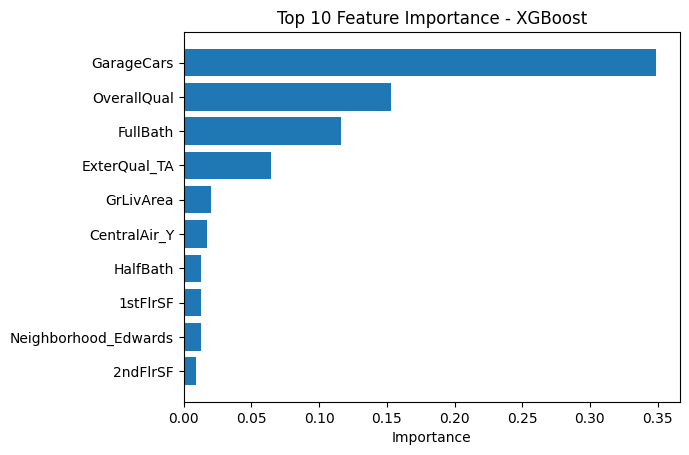

---

---
#feature importance
| Feature | Importance |
|--------:|-------:|
| Feature | Importance|
| GarageCars |   0.348905|
| OverallQual |   0.153117|
| FullBath |   0.115915|
| ExterQual_TA |   0.064580|
| GrLivArea |   0.019853|
| CentralAir_Y |   0.017474|
| HalfBath |   0.012894|
| 1stFlrSF |   0.012870|
| Neighborhood_Edwards |   0.012442|
| 2ndFlrSF |   0.009234|

#Análisis de errores o residuales

---

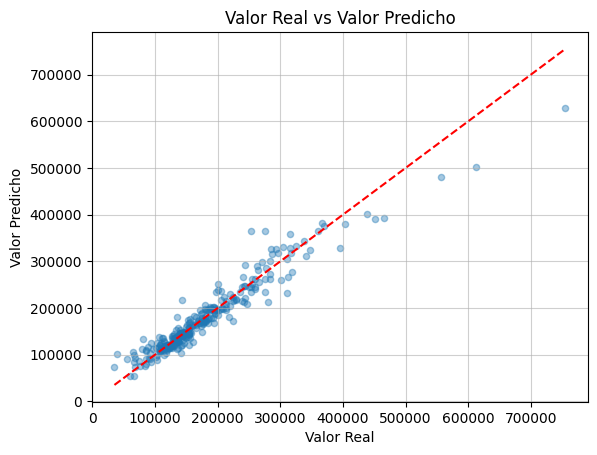

---